# Lab 10 - Learning the XOR Boolean function using an MLP

## Dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch
import torch.nn as nn

In [2]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

for i in range(4):
    print(X[i], "->", y[i][0])

[0. 0.] -> 0.0
[0. 1.] -> 1.0
[1. 0.] -> 1.0
[1. 1.] -> 0.0


XOR gives 1 only when the two inputs are different. The four points cannot be separated by a single straight line, so a single layer perceptron cannot learn it and we need a hidden layer.

## Keras implementation

In [3]:
keras.utils.set_random_seed(42)

model_k = keras.Sequential([
    keras.Input(shape=(2,)),
    layers.Dense(4, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model_k.compile(optimizer=keras.optimizers.Adam(learning_rate=0.1),
                loss="binary_crossentropy", metrics=["accuracy"])
model_k.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
hist_k = model_k.fit(X, y, epochs=500, verbose=0)
loss_k, acc_k = model_k.evaluate(X, y, verbose=0)
print("Final loss:", round(loss_k, 6))
print("Final accuracy:", acc_k)

Final loss: 8.1e-05
Final accuracy: 1.0


In [5]:
pred_k = model_k.predict(X, verbose=0)
for i in range(4):
    print(X[i], "true", y[i][0], "prob", round(float(pred_k[i][0]), 4), "predicted", int(pred_k[i][0] > 0.5))

[0. 0.] true 0.0 prob 0.0001 predicted 0
[0. 1.] true 1.0 prob 0.9999 predicted 1
[1. 0.] true 1.0 prob 0.9999 predicted 1
[1. 1.] true 0.0 prob 0.0001 predicted 0


The model has only 17 parameters. After 500 epochs the output is 0.0001 for (0,0) and (1,1) and 0.9999 for (0,1) and (1,0). Rounding at 0.5 gives exactly the XOR table, so accuracy is 1.0 and the final loss is 0.000081.

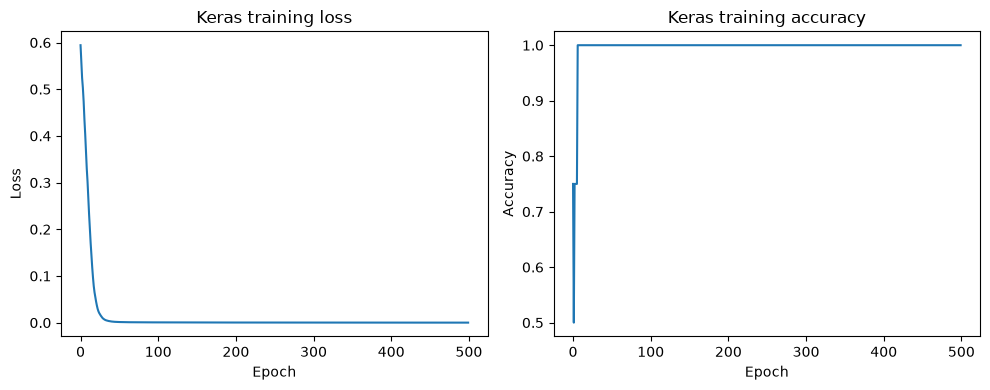

In [6]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(hist_k.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Keras training loss")
plt.subplot(1, 2, 2)
plt.plot(hist_k.history["accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Keras training accuracy")
plt.tight_layout()
plt.show()

Loss starts at 0.5943, falls to 0.0546 by epoch 20 and 0.0014 by epoch 50, then keeps dropping slowly to 0.000081. Accuracy reaches 1.0 at epoch 7, so the model gets the four points right very early and the rest of the training only pushes the probabilities closer to 0 and 1.

## PyTorch implementation

In [7]:
torch.manual_seed(42)

Xt = torch.tensor(X)
yt = torch.tensor(y)

model_p = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model_p.parameters(), lr=0.1)
print(model_p)

Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=1, bias=True)
  (3): Sigmoid()
)


In [8]:
loss_hist_p = []
for epoch in range(500):
    optimizer.zero_grad()
    out = model_p(Xt)
    loss = criterion(out, yt)
    loss.backward()
    optimizer.step()
    loss_hist_p.append(loss.item())
    if (epoch + 1) % 100 == 0:
        print("Epoch", epoch + 1, "loss", round(loss.item(), 6))

Epoch 100 loss 0.008108
Epoch 200 loss 0.002955
Epoch 300 loss 0.001621
Epoch 400 loss 0.001047
Epoch 500 loss 0.000738


In [9]:
with torch.no_grad():
    pred_p = model_p(Xt).numpy()

acc_p = float(np.mean((pred_p > 0.5).astype(np.float32) == y))
for i in range(4):
    print(X[i], "true", y[i][0], "prob", round(float(pred_p[i][0]), 4), "predicted", int(pred_p[i][0] > 0.5))
print("Accuracy:", acc_p)

[0. 0.] true 0.0 prob 0.0001 predicted 0
[0. 1.] true 1.0 prob 0.9999 predicted 1
[1. 0.] true 1.0 prob 0.9975 predicted 1
[1. 1.] true 0.0 prob 0.0002 predicted 0
Accuracy: 1.0


The PyTorch model uses the same 2-4-1 shape but the training loop is written by hand with zero_grad, backward and step. Loss goes from 0.008108 at epoch 100 down to 0.000738 at epoch 500 and all four predictions are correct. The probability for (1,0) is 0.9975, a little lower than the Keras value, because the starting weights are different, but it is still above 0.5 so the prediction is right.

## TensorFlow low level implementation

In [10]:
tf.random.set_seed(42)

W1 = tf.Variable(tf.random.normal([2, 4], stddev=1.0))
b1 = tf.Variable(tf.zeros([4]))
W2 = tf.Variable(tf.random.normal([4, 1], stddev=1.0))
b2 = tf.Variable(tf.zeros([1]))

Xtf = tf.constant(X)
ytf = tf.constant(y)


def forward(x):
    h = tf.nn.relu(tf.matmul(x, W1) + b1)
    return tf.sigmoid(tf.matmul(h, W2) + b2)


def bce(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
    return -tf.reduce_mean(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))

In [11]:
opt = tf.optimizers.Adam(learning_rate=0.1)
loss_hist_t = []

for epoch in range(500):
    with tf.GradientTape() as tape:
        out = forward(Xtf)
        loss = bce(ytf, out)
    grads = tape.gradient(loss, [W1, b1, W2, b2])
    opt.apply_gradients(zip(grads, [W1, b1, W2, b2]))
    loss_hist_t.append(float(loss))
    if (epoch + 1) % 100 == 0:
        print("Epoch", epoch + 1, "loss", round(float(loss), 6))

Epoch 100 loss 0.00355


Epoch 200 loss 0.001488


Epoch 300 loss 0.000844


Epoch 400 loss 0.000554


Epoch 500 loss 0.000395


In [12]:
pred_t = forward(Xtf).numpy()
acc_t = float(np.mean((pred_t > 0.5).astype(np.float32) == y))
for i in range(4):
    print(X[i], "true", y[i][0], "prob", round(float(pred_t[i][0]), 4), "predicted", int(pred_t[i][0] > 0.5))
print("Accuracy:", acc_t)

[0. 0.] true 0.0 prob 0.0007 predicted 0
[0. 1.] true 1.0 prob 0.9999 predicted 1
[1. 0.] true 1.0 prob 0.9999 predicted 1
[1. 1.] true 0.0 prob 0.0007 predicted 0
Accuracy: 1.0


Here the weights are created directly as tf.Variable and the gradients come from GradientTape instead of model.fit. The result is the same, loss drops from 0.00355 at epoch 100 to 0.000395 at epoch 500 and accuracy is 1.0. This shows that Keras and PyTorch are doing this same forward, loss, gradient, update loop inside.

## Comparing the three libraries

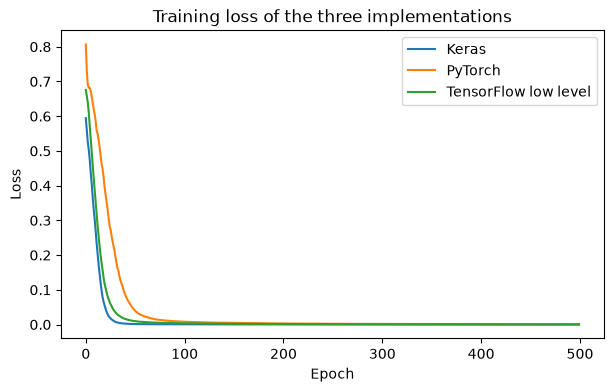

Keras     final loss 8.1e-05 accuracy 1.0
PyTorch   final loss 0.000738 accuracy 1.0
TensorFlow final loss 0.000395 accuracy 1.0


In [13]:
plt.figure(figsize=(7, 4))
plt.plot(hist_k.history["loss"], label="Keras")
plt.plot(loss_hist_p, label="PyTorch")
plt.plot(loss_hist_t, label="TensorFlow low level")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss of the three implementations")
plt.legend()
plt.show()

print("Keras     final loss", round(loss_k, 6), "accuracy", acc_k)
print("PyTorch   final loss", round(loss_hist_p[-1], 6), "accuracy", acc_p)
print("TensorFlow final loss", round(loss_hist_t[-1], 6), "accuracy", acc_t)

All three reach accuracy 1.0 on the four inputs. Final losses are 0.000081 for Keras, 0.000738 for PyTorch and 0.000395 for the TensorFlow low level version. The differences come from the random starting weights, since each library has its own initialiser and seed, not from the method. All three curves fall steeply in the first 50 epochs and then flatten out.

## Effect of hyperparameters

In [14]:
def train_keras(hidden=4, act="relu", lr=0.1, epochs=500, seed=42):
    keras.utils.set_random_seed(seed)
    m = keras.Sequential([
        keras.Input(shape=(2,)),
        layers.Dense(hidden, activation=act),
        layers.Dense(1, activation="sigmoid")
    ])
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
              loss="binary_crossentropy", metrics=["accuracy"])
    m.fit(X, y, epochs=epochs, verbose=0)
    loss, acc = m.evaluate(X, y, verbose=0)
    return loss, acc

### Learning rate

In [15]:
for lr in [0.001, 0.01, 0.1, 0.5]:
    loss, acc = train_keras(lr=lr)
    print("lr", lr, "loss", round(loss, 6), "accuracy", acc)

lr 0.001 loss 0.350548 accuracy 1.0


lr 0.01 loss 0.005688 accuracy 1.0


lr 0.1 loss 8.1e-05 accuracy 1.0


lr 0.5 loss 0.477387 accuracy 0.75


A learning rate of 0.001 is too slow, after 500 epochs the loss is still 0.3505 even though the rounded outputs happen to be correct. 0.01 reaches 0.005688 and 0.1 gives the best loss 0.000081. With 0.5 the loss stays at 0.4774 and accuracy drops to 0.75, so one of the four points is wrong. The learning rate has to be in the middle, too small means slow learning and too large means the updates jump over the minimum.

### Activation function

In [16]:
for act in ["relu", "tanh", "sigmoid"]:
    loss, acc = train_keras(act=act)
    print("activation", act, "loss", round(loss, 6), "accuracy", acc)

activation relu loss 8.1e-05 accuracy 1.0


activation tanh loss 0.000528 accuracy 1.0


activation sigmoid loss 0.002859 accuracy 1.0


All three activations learn XOR with accuracy 1.0. ReLU gives the lowest loss 0.000081, tanh gives 0.000528 and sigmoid gives 0.002859. Sigmoid is the slowest because its gradient becomes very small when the input is large, so the weights move less in the same 500 epochs.

### Number of hidden neurons

In [17]:
for h in [1, 2, 4, 8, 16]:
    loss, acc = train_keras(hidden=h)
    print("hidden neurons", h, "loss", round(loss, 6), "accuracy", acc)

hidden neurons 1 loss 0.477746 accuracy 0.75


hidden neurons 2 loss 0.346634 accuracy 0.75


hidden neurons 4 loss 8.1e-05 accuracy 1.0


hidden neurons 8 loss 6.2e-05 accuracy 1.0


hidden neurons 16 loss 0.000407 accuracy 1.0


With 1 hidden neuron the loss stays at 0.4777 and accuracy is only 0.75, the network is basically a single line so it cannot solve XOR. With 2 neurons it also stays at 0.75 here, 2 is enough in theory but with this seed the training got stuck. From 4 neurons the model is fully correct, 4 gives 0.000081 and 8 gives the lowest loss 0.000062. 16 neurons gives 0.000407 which is worse than 8, so adding more neurons after a point does not help.

### Number of epochs

In [18]:
for e in [50, 100, 300, 500, 1000]:
    loss, acc = train_keras(epochs=e)
    print("epochs", e, "loss", round(loss, 6), "accuracy", acc)

epochs 50 loss 0.001352 accuracy 1.0


epochs 100 loss 0.000602 accuracy 1.0


epochs 300 loss 0.000176 accuracy 1.0


epochs 500 loss 8.1e-05 accuracy 1.0


epochs 1000 loss 2.5e-05 accuracy 1.0


Accuracy is already 1.0 at 50 epochs and the loss keeps going down from 0.001352 to 0.000025 at 1000 epochs. So the extra epochs are not changing the predictions any more, they only make the probabilities more confident. For this small dataset 100 to 500 epochs is enough.

## Decision boundaries

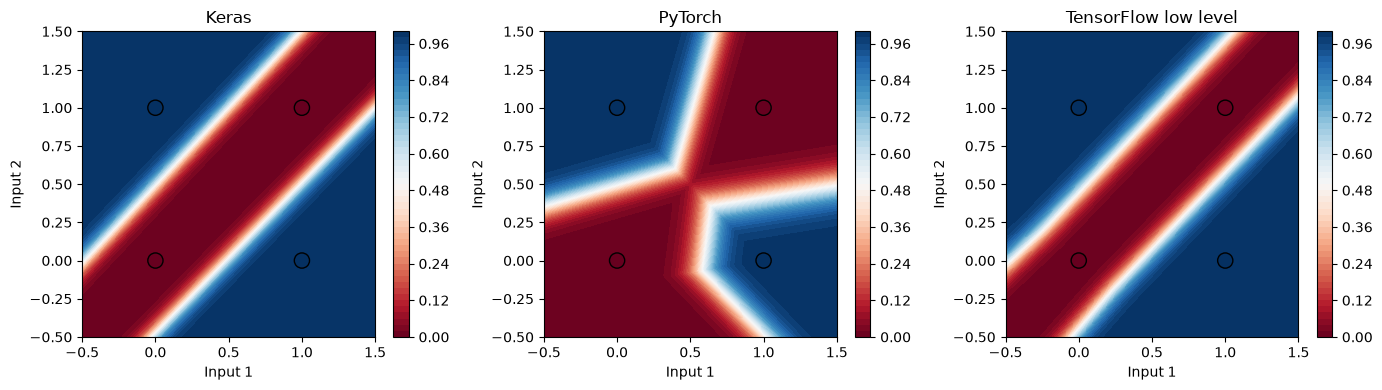

In [19]:
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

zk = model_k.predict(grid, verbose=0).reshape(xx.shape)
with torch.no_grad():
    zp = model_p(torch.tensor(grid)).numpy().reshape(xx.shape)
zt = forward(tf.constant(grid)).numpy().reshape(xx.shape)

titles = ["Keras", "PyTorch", "TensorFlow low level"]
plt.figure(figsize=(14, 4))
for i, z in enumerate([zk, zp, zt]):
    plt.subplot(1, 3, i + 1)
    plt.contourf(xx, yy, z, levels=50, cmap="RdBu")
    plt.colorbar()
    plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap="RdBu", edgecolors="k", s=120)
    plt.title(titles[i])
    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
plt.tight_layout()
plt.show()

Keras and the TensorFlow version give almost the same picture, a red band along the diagonal through (0,0) and (1,1) with blue regions on both sides where (0,1) and (1,0) sit. The PyTorch model splits the plane differently, with three straight pieces meeting near (0.5, 0.5), but the four training points still fall in the correct regions. The boundaries are straight lines joined at corners because ReLU is piecewise linear.

## Conclusion

XOR cannot be solved by a single layer network, but a small MLP with one hidden layer learns it completely. All three implementations, Keras, PyTorch and the TensorFlow low level API, gave accuracy 1.0 on all four inputs using a 2-4-1 network trained for 500 epochs with Adam and binary cross entropy.

Keras needs the least code, PyTorch needs the training loop written out, and the low level TensorFlow version needs the weights, the forward pass and the loss written by hand, which makes it clear what the other two do internally.

From the hyperparameter tests, learning rate 0.1 worked best while 0.001 was too slow and 0.5 broke the training, at least 4 hidden neurons were needed, ReLU converged faster than tanh and sigmoid, and 500 epochs was more than enough since accuracy was already 1.0 by epoch 7.